Libraries and helper functions:

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..')) 

import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.signal import lfilter
from helpers.adaptMultichannel import adaptMultichannel

Simulation:

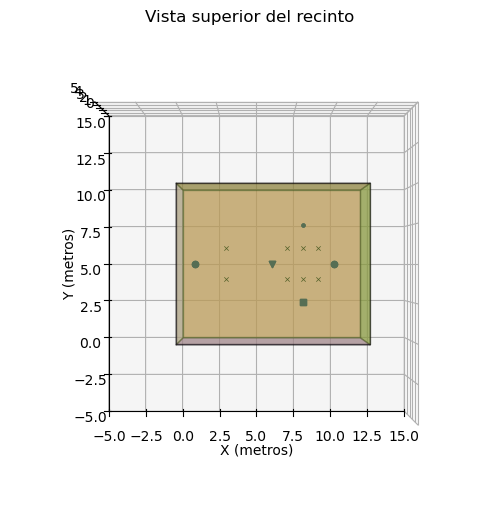

In [2]:
# Create a room
fs = 12000
room = pra.ShoeBox([12, 10, 5], fs=fs, max_order=0)

# Noise source
room.add_source([1, 5, 2.5])

# Reference microphones
room.add_microphone([3, 4, 2.5], fs=fs)
room.add_microphone([3, 6, 2.5], fs=fs)

# Actuators
room.add_source([8, 2.5, 2.5])
room.add_source([6, 5, 2.5])
room.add_source([8, 7.5, 2.5])
room.add_source([10, 5, 2.5])

# Error microphones
room.add_microphone([7, 4, 2.5], fs=fs)
room.add_microphone([7, 6, 2.5], fs=fs)
room.add_microphone([8, 4, 2.5], fs=fs)
room.add_microphone([8, 6, 2.5], fs=fs)
room.add_microphone([9, 4, 2.5], fs=fs)
room.add_microphone([9, 6, 2.5], fs=fs)

fig, ax = room.plot()
ax.view_init(elev=90, azim=-90)
ax.set_title("Vista superior del recinto")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
plt.grid(True)
plt.xlabel('X (metros)')
plt.ylabel('Y (metros)')
plt.show()

Obtain RIRs:

In [3]:
nReferenceMics = 2
nActuators = 4
nErrorMics = 6

room.compute_rir()
referencePaths = [room.rir[m][0] for m in range(nReferenceMics)]
primaryPaths = [room.rir[m][0] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]
secondaryPaths = [[room.rir[m][s] for s in range(1, nActuators + 1)] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]

# Shape RIRs for efficient convolution
referencePaths = np.array([
    np.pad(h, (0, max(len(h) for h in referencePaths) - len(h)))
    for h in referencePaths
])

primaryPaths = np.array([
    np.pad(h, (0, max(len(h) for h in primaryPaths) - len(h)))
    for h in primaryPaths
])

maxLen = max(len(h) for row in secondaryPaths for h in row)
secondaryPaths = np.array([
    [np.pad(h, (0, maxLen - len(h))) for h in row]
    for row in secondaryPaths
])

print("Reference paths shape: ", referencePaths.shape)
print("Primary paths shape: ", primaryPaths.shape)
print("Secondary paths shape: ", secondaryPaths.shape)

Reference paths shape:  (2, 161)
Primary paths shape:  (6, 365)
Secondary paths shape:  (6, 4, 210)


Algorithm:

Notice how, compared with FxLMS.ipynb, MFxLMS allows for a slightly greater step size under equal conditions

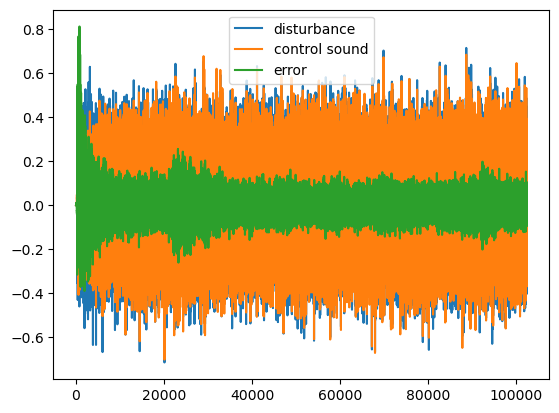

In [14]:
# Disturbance
blocklength = 1024
nBlocks = 100
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter matrix definition
nTaps = 512
wFilter = np.ones((nActuators, nReferenceMics, nTaps)) * 0.01
mu = 1.1
wDummy = wFilter.copy()

# States for online time domain convolution
referenceStates = np.zeros((nReferenceMics, referencePaths.shape[1] - 1))
disturbanceStates = np.zeros((nErrorMics, primaryPaths.shape[1] - 1))
wOutputsStates = np.zeros((nActuators, nReferenceMics, nTaps - 1))
dummyControlStates = np.zeros((nErrorMics, nActuators, nReferenceMics, nTaps - 1))
controlStates = np.zeros((nErrorMics, nActuators, secondaryPaths.shape[2] - 1))
controlHatStates = np.zeros((nErrorMics, nActuators, secondaryPaths.shape[2] - 1))
filteredReferencesStates = np.zeros((nErrorMics, nActuators, nReferenceMics, secondaryPaths.shape[2] - 1))

# For testing
xRef = np.zeros((nReferenceMics, N))
d = np.zeros((nErrorMics, N))
u = np.zeros((nActuators, N))
y = np.zeros((nErrorMics, N))
e = np.zeros((nErrorMics, N))

for k in range(nBlocks):
    # Block samples of X (simulation)
    xSignal = x[k*blocklength : (k+1)*blocklength]
    
    ################## Physical signals ##################

    # Reference signals (simulation)
    refSignals = np.zeros((nReferenceMics, blocklength))
    for m in range(nReferenceMics):
        refSignals[m], referenceStates[m] = lfilter(
            referencePaths[m],  
            [1],                
            xSignal,            
            zi=referenceStates[m]
        )
        
    # Disturbance signals (simulation)
    dSignals = np.zeros((nErrorMics, blocklength))
    for m in range(nErrorMics):
        dSignals[m], disturbanceStates[m] = lfilter(
            primaryPaths[m],
            [1],
            xSignal,            
            zi=disturbanceStates[m]
        )
        
    # Actuators signals
    wOutputSignals = np.zeros((nActuators, nReferenceMics, blocklength))
    for nActuator in range(nActuators):
        for nReference in range(nReferenceMics):
            wOutputSignals[nActuator][nReference], wOutputsStates[nActuator][nReference] = lfilter(
                wFilter[nActuator][nReference],
                [1],
                refSignals[nReference],
                zi=wOutputsStates[nActuator][nReference]
            )
    actuatorsSignals = np.sum(wOutputSignals, axis=1)        
    
    # Control and Errors signals (simulation)
    controlSignals = np.zeros((nErrorMics, nActuators, blocklength))
    for nError in range(nErrorMics):
        for nActuator in range(nActuators):
            controlSignals[nError][nActuator], controlStates[nError][nActuator] = lfilter(
                secondaryPaths[nError][nActuator],
                [1],
                actuatorsSignals[nActuator],
                zi=controlStates[nError][nActuator]
            )
    controlSignals = np.sum(controlSignals, axis=1)

    errorSignals = dSignals - controlSignals
    
    ################## Algorithm ##################
                
    # Filter de actuator signals by the plant model (in this case ideal)
    controlHatSignals = np.zeros((nErrorMics, nActuators, blocklength))
    for nError in range(nErrorMics):
        for nActuator in range(nActuators):
            controlHatSignals[nError][nActuator], controlHatStates[nError][nActuator] = lfilter(
                secondaryPaths[nError][nActuator],
                [1],
                actuatorsSignals[nActuator],
                zi=controlHatStates[nError][nActuator]
            )
    controlHatSignals = np.sum(controlHatSignals, axis=1)

    # Compute the reconstructed desired signal
    dHatSignals = errorSignals + controlHatSignals

    # Compute the filtered reference matrix
    filteredReferences = np.zeros((nErrorMics, nActuators, nReferenceMics, blocklength))
    for nReferenceMic in range(nReferenceMics):
        for nActuator in range(nActuators):
            for nError in range(nErrorMics):
                filteredReferences[nError][nActuator][nReferenceMic], filteredReferencesStates[nError][nActuator][nReferenceMic] = lfilter(
                secondaryPaths[nError][nActuator],
                [1],
                refSignals[nReferenceMic],
                zi=filteredReferencesStates[nError][nActuator][nReferenceMic]
            )
                
    # Filter the reference matrix by the dummy adaptive filter
    dummyControlSignals = np.zeros((nErrorMics, blocklength))
    for nError in range(nErrorMics):
        for nActuator in range(nActuators):
            for nReference in range(nReferenceMics):
                dummyContribution, dummyControlStates[nError][nActuator][nReference] = lfilter(
                    wDummy[nActuator][nReference],
                    [1],
                    filteredReferences[nError][nActuator][nReference],
                    zi=dummyControlStates[nError][nActuator][nReference]
                )

                dummyControlSignals[nError] += dummyContribution

    # Compute the error signal for MFxLMS
    eHatSignals = dHatSignals - dummyControlSignals

    # LMS algorithm
    wDummy = adaptMultichannel(
        filteredReferences,
        eHatSignals,
        nTaps,
        blocklength,
        wDummy,
        mu
    )

    wFilter = wDummy.copy()
    
    ################## For testing ##################
    start = k * blocklength
    end = (k + 1) * blocklength

    xRef[:, start:end] = refSignals
    d[:, start:end] = dSignals
    u[:, start:end] = actuatorsSignals
    y[:, start:end] = controlSignals
    e[:, start:end] = errorSignals

plt.plot(d[0], label="disturbance")
plt.plot(y[0], label="control sound")
plt.plot(e[0], label="error")
plt.legend()
plt.show()
